# A/B Test Analysis: Delivery Time Optimization

**Dataset:** `data/experiment_lesson_4.csv` — Courier delivery records from a pizza delivery app

**Context:** A data science team built a new routing algorithm that lets couriers plan their last orders of the day along their commute home ("on the way" feature). An A/B test was run on two equal groups of couriers. The goal is to decide whether to roll out the new algorithm to all couriers.

**Topics:**
1. Dataset overview
2. Group balance check
3. Distribution analysis by district
4. Normality testing — sampling issues on large datasets
5. Statistical hypothesis testing — T-test and alternatives
6. Effect size and business decision

## Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `order_id` | int | Unique order identifier |
| `delivery_time` | float | Delivery time in minutes |
| `district` | str | Delivery district |
| `experiment_group` | str | Group assignment: `control` (old algorithm) or `test` (new "on the way" algorithm) |

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Dataset Overview

In [54]:
df = pd.read_csv('data/experiment_lesson_4.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (20196, 4)


,order_id,delivery_time,district,experiment_group
0,3159,44.0,Purlieus,control
1,10426,51.0,Purlieus,control
2,9155,46.0,Purlieus,control
3,10699,34.0,Purlieus,control
4,10061,43.0,Purlieus,control


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20196 entries, 0 to 20195
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          20196 non-null  int64  
 1   delivery_time     20196 non-null  float64
 2   district          20196 non-null  str    
 3   experiment_group  20196 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 631.3 KB


## 2. Group Balance Check

A valid A/B test requires both groups to be approximately equal in size.
A large imbalance can bias the statistical test.

In [56]:
group_counts = df['experiment_group'].value_counts()
print(group_counts)
print(f'\nAbsolute difference: {abs(group_counts.values[0] - group_counts.values[1])} orders')

experiment_group
test       10104
control    10092
Name: count, dtype: int64

Absolute difference: 12 orders


## 3. Distribution Analysis by District

Before running any test, visualize the delivery time distributions for each group.
Checking by district helps detect potential confounding — if districts differ in baseline delivery times,
and the groups are not balanced across districts, the comparison could be misleading.

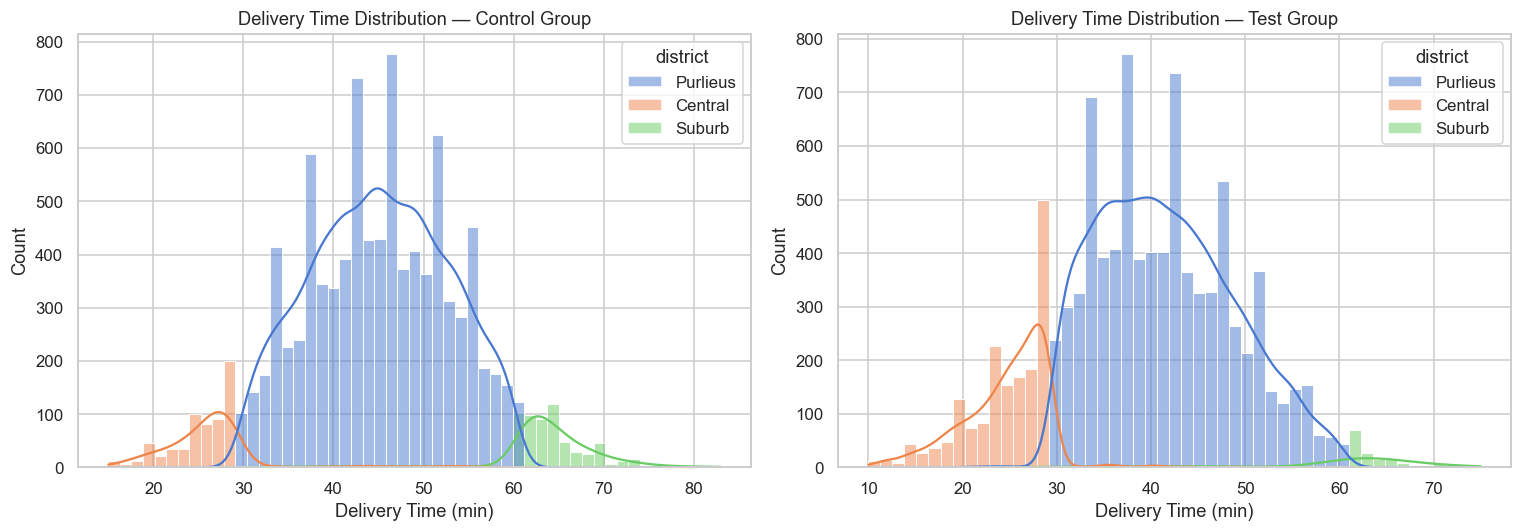

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group in zip(axes, ['control', 'test']):
    sns.histplot(
        x='delivery_time', hue='district',
        data=df.query(f'experiment_group == "{group}"'),
        ax=ax, kde=True, alpha=0.5
    )
    ax.set_title(f'Delivery Time Distribution — {group.capitalize()} Group')
    ax.set_xlabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

## 4. Normality Testing

The T-test assumes the data is approximately normally distributed. We use the **Shapiro-Wilk test** to check this.

**Problem with large samples:** For $n > 5000$, the Shapiro-Wilk test becomes extremely sensitive
and rejects normality even for trivially small deviations. The p-value is also unreliable (scipy warns about this).

**Common workaround — sampling:** Draw a random subsample (e.g. $n = 1000$) and run the test on it.
However, this introduces instability: different random seeds give different conclusions.

**Better alternative:** Use `pingouin`'s `normaltest` method (D'Agostino & Pearson test),
which is designed for large samples and tests skewness and kurtosis jointly.

In [58]:
# Sampling approach — one draw per group
sample_test    = df[df['experiment_group'] == 'test']['delivery_time'].sample(1000, random_state=17)
sample_control = df[df['experiment_group'] == 'control']['delivery_time'].sample(1000, random_state=17)

print('Shapiro-Wilk p-values (single sample, n=1000):')
print(f'  test:    {stats.shapiro(sample_test).pvalue:.3f}')
print(f'  control: {stats.shapiro(sample_control).pvalue:.3f}')

Shapiro-Wilk p-values (single sample, n=1000):
  test:    0.139
  control: 0.124


Rejection rate across 1000 random samples: 25%
=> Single-sample Shapiro-Wilk is unreliable — results flip depending on the random draw.


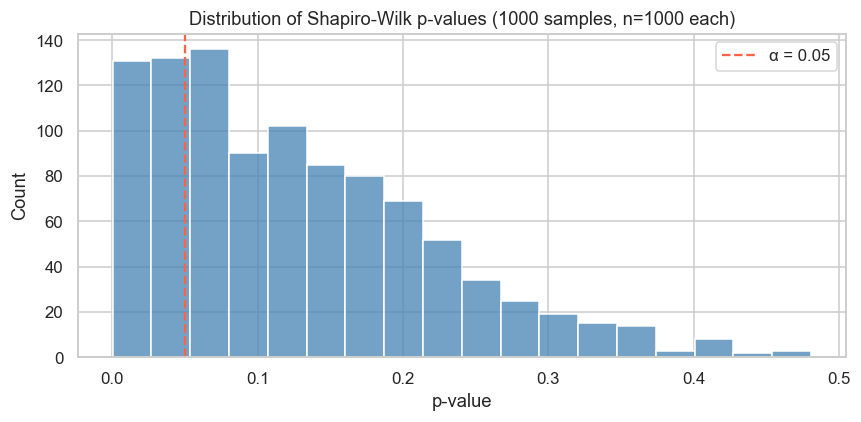

In [59]:
# Bootstrap stability check — how often does sampling give a different conclusion?
pvalues_test = [
    stats.shapiro(df[df['experiment_group'] == 'test']['delivery_time'].sample(1000)).pvalue
    for _ in range(1000)
]

reject_rate = np.mean(np.array(pvalues_test) < 0.05)
print(f'Rejection rate across 1000 random samples: {reject_rate:.0%}')
print('=> Single-sample Shapiro-Wilk is unreliable — results flip depending on the random draw.')

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(pvalues_test, ax=ax, color='steelblue')
ax.axvline(0.05, color='tomato', linestyle='--', label='α = 0.05')
ax.set_title('Distribution of Shapiro-Wilk p-values (1000 samples, n=1000 each)')
ax.set_xlabel('p-value')
ax.legend()
plt.tight_layout()
plt.show()

In [60]:
# Preferred approach: D'Agostino-Pearson test via pingouin (designed for large samples)
pg.normality(data=df, dv='delivery_time', group='experiment_group', method='normaltest')

,W,pval,normal
experiment_group,,,
control,0.253498,0.880955,True
test,7.024157,0.029835,False


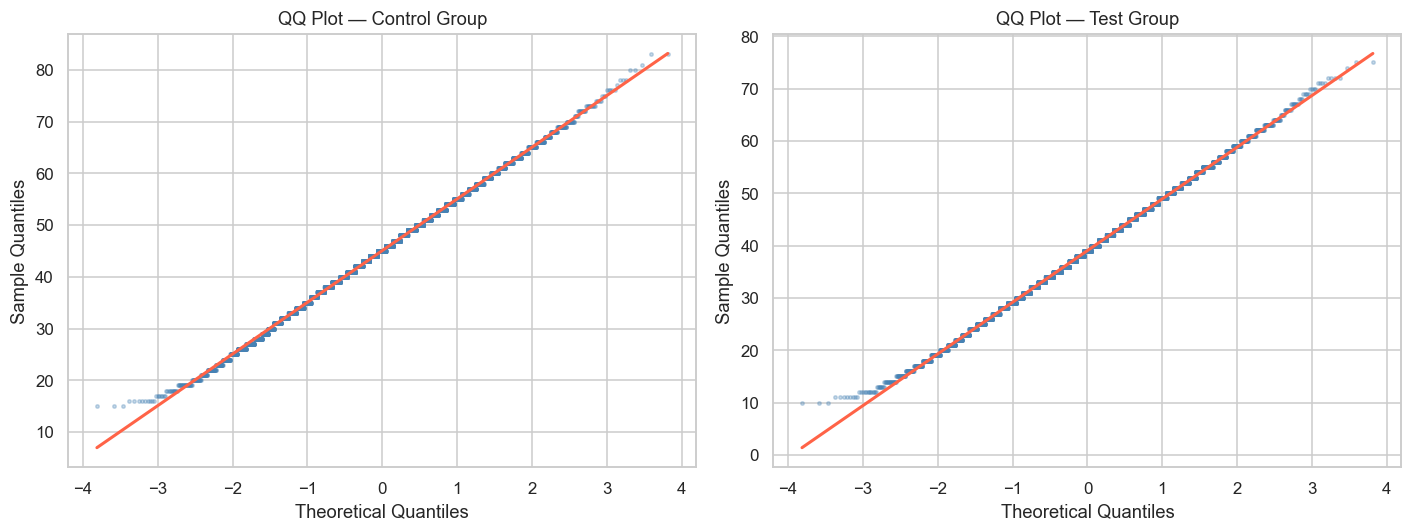

Slight deviation from the line in the tails — mild non-normality.
For n > 10,000, the Central Limit Theorem ensures the t-test remains valid.


In [61]:
# QQ plots — visual normality check
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, group in zip(axes, ['control', 'test']):
    data = df.query(f'experiment_group == "{group}"')['delivery_time']
    (osm, osr), (slope, intercept, _) = stats.probplot(data)
    ax.scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
    ax.plot(osm, slope * np.array(osm) + intercept, color='tomato', linewidth=2)
    ax.set_title(f'QQ Plot — {group.capitalize()} Group')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

print('Slight deviation from the line in the tails — mild non-normality.')
print('For n > 10,000, the Central Limit Theorem ensures the t-test remains valid.')

In [62]:
# Standard deviation by group
test    = df[df['experiment_group'] == 'test']['delivery_time']
control = df[df['experiment_group'] == 'control']['delivery_time']

print(f'Std dev — test:    {np.std(test):.2f} min')
print(f'Std dev — control: {np.std(control):.2f} min')
print(f'Mean    — test:    {np.mean(test):.2f} min')
print(f'Mean    — control: {np.mean(control):.2f} min')

Std dev — test:    9.88 min
Std dev — control: 9.99 min
Mean    — test:    39.05 min
Mean    — control: 45.07 min


## 5. Statistical Hypothesis Testing

**Hypotheses:**
- $H_0$: Mean delivery time is equal in test and control groups
- $H_1$: Mean delivery time differs between the groups

We apply multiple tests to cross-validate the result:

| Test | Assumption | Use case |
|------|-----------|----------|
| **Student's T-test** | Approx. normal, large $n$ | Primary test |
| **Mann-Whitney U** | No normality required | Ordinal / non-normal data |
| **Yuen's trimmed T-test** | Trims extreme values (20%) | Robust to outliers |
| **Permutation test** | No distributional assumption | Exact, model-free |

Significance level: $\alpha = 0.05$

In [63]:
# Student's T-test (full data)
result = stats.ttest_ind(test, control)
print(f"T-statistic: {result.statistic:.3f}")
print(f"P-value:     {result.pvalue}")
print(f"=> {'Reject H₀' if result.pvalue < 0.05 else 'Fail to reject H₀'}")

T-statistic: -43.036
P-value:     0.0
=> Reject H₀


In [64]:
# Pingouin T-test — includes Cohen's d (effect size)
# Cohen's d: how many standard deviations apart are the group means
pg.ttest(test, control)

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-43.035552,20191.127788,two-sided,0.0,"[-6.29, -5.74]",0.605658,1.0,inf


In [65]:
# Mann-Whitney U test — non-parametric alternative
# Tests whether values from one group tend to be larger than the other
result_mw = stats.mannwhitneyu(x=test, y=control)
print(f'Mann-Whitney U statistic: {result_mw.statistic:.0f}')
print(f'P-value:                  {result_mw.pvalue}')
print(f"=> {'Reject H₀' if result_mw.pvalue < 0.05 else 'Fail to reject H₀'}")

Mann-Whitney U statistic: 33985060
P-value:                  0.0
=> Reject H₀


In [66]:
# Yuen's trimmed T-test (trim=0.2 → drop bottom and top 20%)
# More robust to outliers and heavy tails
result_yuen = stats.ttest_ind(test, control, trim=0.2)
print(f'Yuen T-statistic: {result_yuen.statistic:.3f}')
print(f'P-value:          {result_yuen.pvalue}')
print(f"=> {'Reject H₀' if result_yuen.pvalue < 0.05 else 'Fail to reject H₀'}")

Yuen T-statistic: -42.161
P-value:          0.0
=> Reject H₀


Observed statistic: 6.018 min
P-value:            0.0002

The null distribution hovers around 0 (±0.2 min).
An observed difference of 6.0 min is far in the tail → strong evidence against H₀.


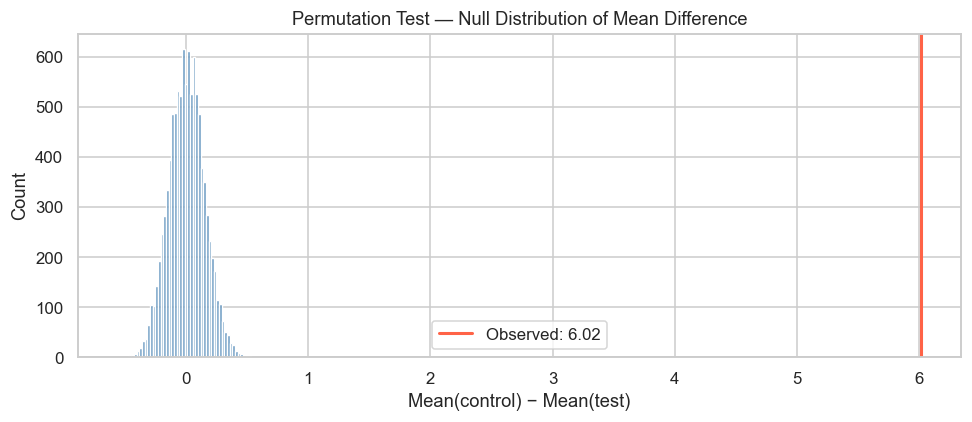

In [67]:
# Permutation test — shuffles labels 9999 times to build the null distribution
# The observed statistic is compared against this empirical null
def diff_of_means(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

result_perm = stats.permutation_test(
    (control, test),
    statistic=diff_of_means,
    permutation_type='independent',
    n_resamples=9999,
    alternative='two-sided'
)

print(f'Observed statistic: {result_perm.statistic:.3f} min')
print(f'P-value:            {result_perm.pvalue}')
print()
print('The null distribution hovers around 0 (±0.2 min).')
print(f'An observed difference of {abs(result_perm.statistic):.1f} min is far in the tail → strong evidence against H₀.')

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(result_perm.null_distribution, ax=ax, color='steelblue', bins=50)
ax.axvline(result_perm.statistic, color='tomato', linewidth=2, label=f'Observed: {result_perm.statistic:.2f}')
ax.set_title('Permutation Test — Null Distribution of Mean Difference')
ax.set_xlabel('Mean(control) − Mean(test)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Effect Size and Business Decision

Statistical significance tells us the result is unlikely due to chance.
**Practical significance** tells us whether the effect is large enough to matter for the business.

In [68]:
relative_change = (np.mean(test) - np.mean(control)) / np.mean(control) * 100
absolute_change = np.mean(test) - np.mean(control)

print(f'Control mean:    {np.mean(control):.2f} min')
print(f'Test mean:       {np.mean(test):.2f} min')
print(f'Absolute change: {absolute_change:.2f} min')
print(f'Relative change: {relative_change:.2f}%')

Control mean:    45.07 min
Test mean:       39.05 min
Absolute change: -6.02 min
Relative change: -13.35%


## Conclusion

**Roll out the new algorithm.** All four statistical tests (T-test, Mann-Whitney, Yuen, Permutation) reject $H_0$ at $\alpha = 0.05$.

Key findings:
- Average delivery time decreased by **~13.4%** in the test group
- The effect is consistent across all robustness checks
- Cohen's d ≈ 0.61 indicates a **medium-to-large** practical effect
- Both groups are balanced (difference of only 12 orders out of ~20,000)

The "on the way home" routing feature significantly reduces delivery time and should be deployed to all couriers.